In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Data Cleaning & Preparation:

In [2]:
df = pd.read_excel('/content/dataset.xlsx')
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [4]:
df.shape

(648, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [6]:
df.describe()

,Unnamed: 0,Year,Place,Points,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
count,648.000000,648.000000,648.000000,648.000000,648.000000,281.000000,648.000000,648.000000,648.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,480.000000,304.000000
mean,324.500000,2006.543210,11.858025,77.783951,0.566358,1.327402,0.728395,2.636140,0.044753,0.725833,...,0.571246,113.905349,0.056576,5.782158,0.201399,3.900415,0.580913,-6.516718,0.521286,5.406843
std,187.205769,4.016733,6.795186,63.301464,0.495960,0.470103,0.445131,2.089733,0.034887,0.186675,...,0.136131,24.958535,0.050582,3.453922,0.172561,0.485164,0.493922,2.358372,0.236548,0.288879
min,1.000000,1998.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.424200,0.000000,0.064730,...,0.183719,64.971000,0.023994,0.000000,0.026513,1.000000,0.000000,-21.878000,0.017786,4.375630
25%,162.750000,2004.000000,6.000000,30.000000,0.000000,1.000000,0.000000,1.017664,0.017946,0.607444,...,0.489436,91.968500,0.032869,2.250000,0.090076,4.000000,0.000000,-7.735000,0.328387,5.251099
50%,324.500000,2007.000000,12.000000,62.000000,1.000000,1.000000,1.000000,2.054728,0.035151,0.759969,...,0.574584,121.357500,0.041742,6.000000,0.136240,4.000000,1.000000,-6.169500,0.525902,5.464790
75%,486.250000,2010.000000,17.000000,110.000000,1.000000,2.000000,1.000000,3.864811,0.065451,0.881004,...,0.669654,130.163000,0.060256,9.000000,0.277933,4.000000,1.000000,-4.894000,0.723856,5.579380
max,648.000000,2012.000000,28.000000,387.000000,1.000000,2.000000,1.000000,9.795199,0.158867,0.999169,...,0.894179,211.985000,0.505107,11.000000,0.987510,7.000000,1.000000,-2.352000,0.971989,6.148232


In [7]:
#missing values check

df.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


Handling Missing Values Strategy

> **Artist.gender and Group.Solo (more than 50% missing)**

  Noticed that Artist.gender and Group.Solo have 422 NAs each, probably the same rows. I filled them with "Unknown" because,if we drop this, we will be left with only 226 rows.(llosses around 60% data).



> **Audio features(166 missing each)**

  For the audio features like danceability, energy (166 NAs), I used median imputation because,it handles outliers better than mean.









> **Happiness and Semi.Final.Number**
  I dropped Happiness column since 344/1000 is too many missing and unclear what it represents.
  
  Semi.Final.Number has 367 NAs - I filled with 0 assuming those auto-qualified to final.



In [8]:
df['Artist.gender'] = df['Artist.gender'].fillna('Unknown')
df['Group.Solo'] = df['Group.Solo'].fillna('Unknown')

audio_cols = ['energy','duration','acousticness','danceability','tempo',
              'speechiness','key','liveness','time_signature','mode',
              'loudness','valence']
df[audio_cols] = df[audio_cols].fillna(df[audio_cols].median())

df['Semi.Final.Number'].fillna(0, inplace=True)
df.drop('Happiness', axis=1, inplace=True)

/tmp/ipykernel_1432/3415978275.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Semi.Final.Number'].fillna(0, inplace=True)


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


In [10]:
# Task 2: Relationship with Points

df['Artist.gender'].unique()

array(['Male', 'Female', 'Both', 'Unknown'], dtype=object)

In [11]:
df['Group.Solo'].unique()

array(['Solo', 'Group', 'Unknown'], dtype=object)

In [12]:
print("Average Points by Artist Gender:")
gender_stats = df.groupby('Artist.gender')['Points'].agg(['mean', 'median', 'count']).round(1)
print(gender_stats)

print("\nAverage Points by Group/Solo:")
group_stats = df.groupby('Group.Solo')['Points'].agg(['mean', 'median', 'count']).round(1)
print(group_stats)

Average Points by Artist Gender:
                mean  median  count
Artist.gender                      
Both            75.1    64.0     31
Female         110.2    99.0    101
Male           116.4   105.5     94
Unknown         61.6    49.0    422

Average Points by Group/Solo:
             mean  median  count
Group.Solo                      
Group        96.7    84.0     73
Solo        113.4   105.0    153
Unknown      61.6    49.0    422


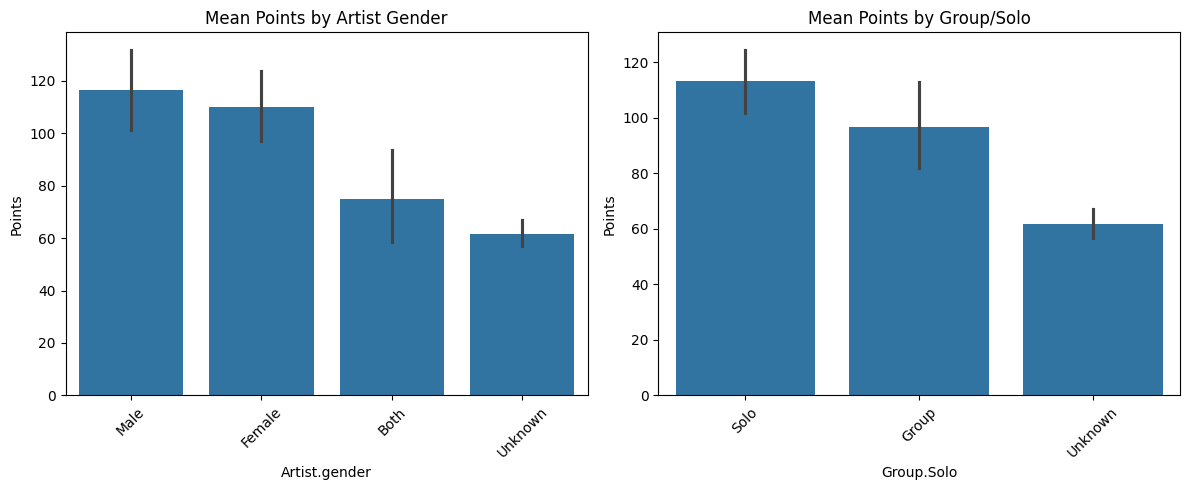

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='Artist.gender', y='Points', ax=ax1)
ax1.set_title('Mean Points by Artist Gender')
ax1.tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Group.Solo', y='Points', ax=ax2)
ax2.set_title('Mean Points by Group/Solo')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



* Male artists avg 116 pts, Female 110 pts (small edge to males)
* Solo acts (113 pts) beat Groups (97 pts) slightly
* "Unknown" category drags averages down (62 pts)

Overall observation is that solo performances tend to perform slightly better than group performances, while the difference between male and female artists is relatively small.


In [14]:
#Task 3:Feature selection

audio_features = ['energy', 'duration', 'acousticness', 'danceability',
                  'tempo', 'speechiness', 'key', 'liveness', 'time_signature',
                  'mode', 'loudness', 'valence']

# Target = Points
y = df['Points']

features = ['Year', 'Artist.gender', 'Group.Solo', 'Song.In.English'] + audio_features
X = df[features].copy()
print(X)

     Year Artist.gender Group.Solo  Song.In.English    energy   duration  \
0    2009          Male       Solo                1  0.678258  183.18476   
1    2009        Female      Group                1  0.794093  179.87873   
2    2009        Female       Solo                0  0.574628  227.97333   
3    2009        Female       Solo                1  0.672746  178.45660   
4    2009          Both      Group                0  0.733959  182.83057   
..    ...           ...        ...              ...       ...        ...   
643  2010       Unknown    Unknown                0  0.913209  177.68444   
644  2010       Unknown    Unknown                1  0.759969  182.18481   
645  2010       Unknown    Unknown                0  0.759969  182.18481   
646  2010       Unknown    Unknown                1  0.911007  183.01342   
647  2010       Unknown    Unknown                1  0.413793  180.32281   

     acousticness  danceability     tempo  speechiness   key  liveness  \
0        0.56

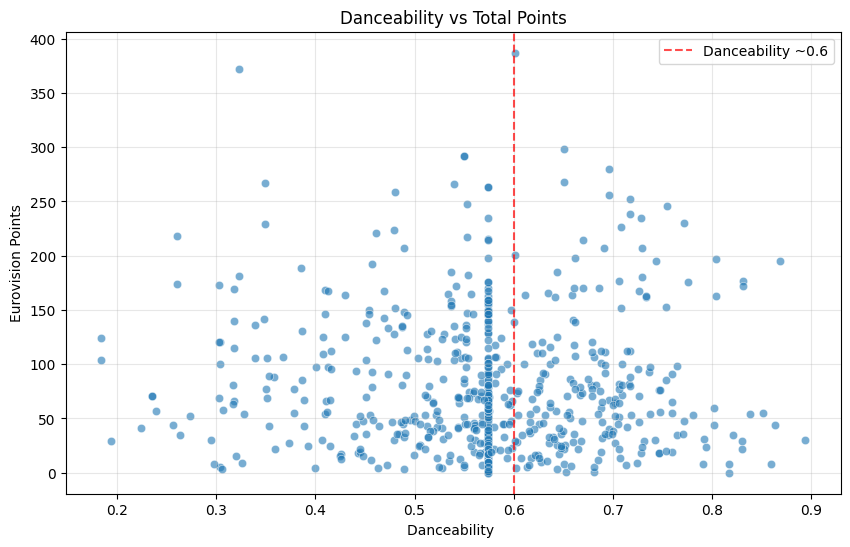

In [15]:
#Task 4: Create a scatter plot to visualize the relationship between danceability and Points.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='danceability', y='Points', alpha=0.6)
plt.title('Danceability vs Total Points')
plt.xlabel('Danceability ')
plt.ylabel('Eurovision Points')
plt.axvline(x=0.6, color='red', linestyle='--', alpha=0.7, label='Danceability ~0.6')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

From the scatter plot, most of the songs that received higher points have a danceability score between 0.6 and 0.8. Songs with very low danceability (below 0.5) or very high danceability (above 0.9) tend to get fewer points.

Thus suggests that songs which are moderately danceable may perform better in the Eurovision contest.

**Hypothesis**
Songs with a moderste level of danceability are more likely to appeal to a wider audience and therefore receive higher points.
Songs that are too slow and too energetic might not appeal to everyone

In [20]:
#Task 5: Prepare the data for modeling by transforming all categorical features into a numerical format.

from sklearn.preprocessing import OneHotEncoder

cat_features = ['Artist.gender', 'Group.Solo']

num_features = [col for col in X.columns if col not in cat_features]
print("Categorical:", cat_features)
print("Numeric:", num_features[:5], "...")


Categorical: ['Artist.gender', 'Group.Solo']
Numeric: ['Year', 'Song.In.English', 'energy', 'duration', 'acousticness'] ...


In [21]:
#One-hot encode
X_sample = X.copy()

# Get dummies for categoricals
X_encoded = pd.get_dummies(X_sample, columns= cat_features,
                          drop_first=True, dtype=float)

print(f"Shape: {X_encoded.shape}")
print("\nNew columns:")
print(X_encoded.head())


Shape: (648, 19)

New columns:
   Year  Song.In.English    energy   duration  acousticness  danceability  \
0  2009                1  0.678258  183.18476      0.563170      0.598360   
1  2009                1  0.794093  179.87873      0.068711      0.604542   
2  2009                0  0.574628  227.97333      0.654078      0.367344   
3  2009                1  0.672746  178.45660      0.119194      0.513202   
4  2009                0  0.733959  182.83057      0.323643      0.590592   

     tempo  speechiness   key  liveness  time_signature  mode  loudness  \
0  102.984     0.027817   9.0  0.078643             3.0   0.0    -9.082   
1  105.972     0.024996   8.0  0.084805             4.0   1.0    -6.059   
2  124.005     0.043751   1.0  0.923905             4.0   1.0    -8.655   
3  128.021     0.034855  10.0  0.143708             4.0   1.0    -4.536   
4  116.107     0.032406   1.0  0.079322             4.0   0.0    -4.427   

    valence  Artist.gender_Female  Artist.gender_Male  

In [23]:
#Task 6: Split the data, train a Gradient Boosting Regressor and evaluate its Mean Absolute Error (MAE).

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Test predictions
y_pred = gb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error = {mae}")

Mean Absolute Error = 45.051471525824134


The Mean Absolute Error of my model is about 45. This means that, on average, the model's predicted Eurovision points differ from the actual points by around 45 points.
if a song actually receives 200 points, the model might predict something around 155 to 245 points.

In [24]:
# Task 7: Save with pickle
import pickle

# Save model
with open('eurovision_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_encoded.columns.tolist(), f)


# Download
from google.colab import files
files.download('eurovision_model.pkl')
files.download('feature_names.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####Bonus Task

In [25]:
#Enhance your application with a new feature that shows a country's historical "best friend" in voting

voting_df = pd.read_excel('dataset.xlsx', sheet_name='Voting Final')


In [29]:
voting_df.head()

,Year,Country,Giver,Score
0,2009,Lithuania,Albania,0
1,2009,Israel,Albania,0
2,2009,France,Albania,2
3,2009,Sweden,Albania,1
4,2009,Croatia,Albania,0


In [31]:
voting_df.shape

(12131, 4)

In [32]:
voting_df['Giver'].unique()

array(['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan',
       'Belarus', 'Belgium', 'Bosnia-Herzegovina', 'Bulgaria', 'Croatia',
       'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland',
       'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland',
       'Ireland', 'Israel', 'Latvia', 'Lithuania', 'Macedonia', 'Malta',
       'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'Norway',
       'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia',
       'Serbia and Montenegro', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland', 'Turkey', 'Ukraine', 'United Kingdom', 'Italy'],
      dtype=object)

In [35]:
#findbestfriend
def find_best_friend(country):
    friend_df = voting_df[voting_df['Country'] == country]
    best_friend = friend_df.groupby('Giver')['Score'].sum().idxmax()
    return best_friend

print(find_best_friend('Albania'))


Macedonia
